# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [48]:
weight = 3
bias = -13

### Logistic Regression Predictions

In [49]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

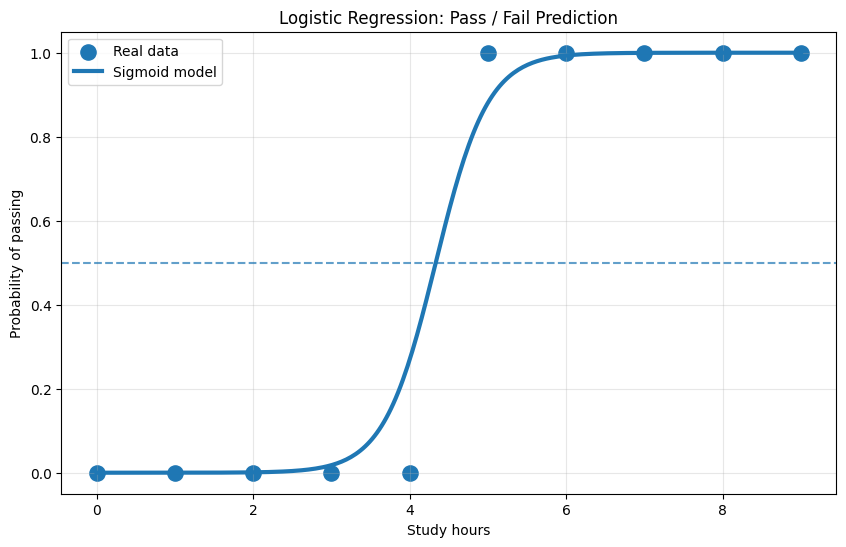

In [50]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions

1. What does the weight control?
   - Weight controls the steepness of the sigmoid curve — higher weight means sharper, more decisive transition from 0 to 1.
2. What does the bias control?
    - Bias shifts the curve left or right along the x-axis without changing the shape.
3. What happens when the sigmoid becomes steeper?
    - Steeper sigmoid means the model is more confident — probabilities stay near 0 or 1
6. Where is the decision boundary?
    - Decision boundary is at x = −bias / weight, the point where predicted probability = 0.5
8. Which students are difficult to classify?
    - The student at 4 hours (fails) and 5 hours (pass) are hardest to classify because they are the closest to the boundary, so small changes in weight or bias can change the prediction.
10. Why is logistic regression better than linear regression here?
    - We are not predict their score but their chance of pass or fail, so that's why logistic regression is chosen. What we are doing is classification, so output should be probability of 0 or 1 rather than some continuous value which is meaningless if we want classification.

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [54]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
    - x = age
4. Choose one binary target y.
    - y = survived
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

In [112]:
import numpy
x = df["Age"].values
y = df["Survived"].values

x = np.array(x)
y = np.array(y)

In [113]:
x = x[:20]
y = y[:20]
w = 1
b = -30
z = w*x + b

p = 1 / (1 + np.exp(-z))

y_pred = (p > 0.5).astype(int)

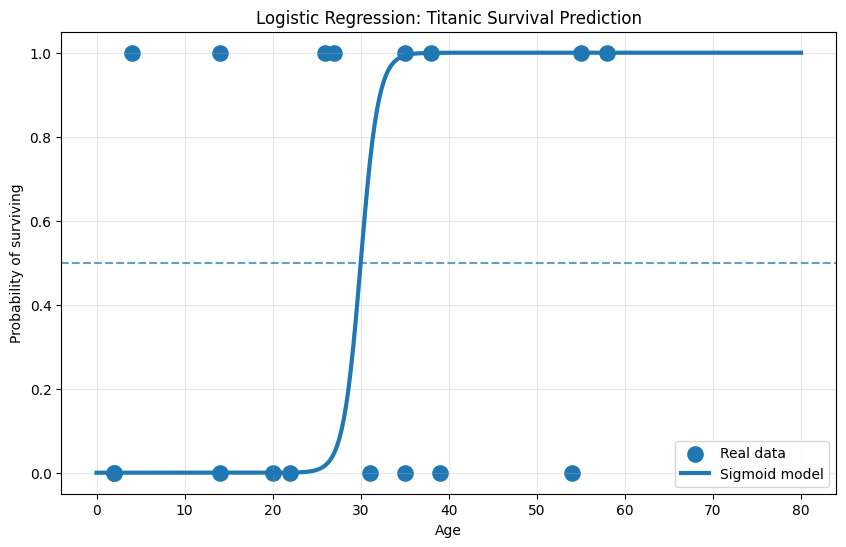

In [114]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 80, 300)
z_curve = w * x_curve + b
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Age")
plt.ylabel("Probability of surviving")
plt.title("Logistic Regression: Titanic Survival Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

mask = ~np.isnan(x)
x_clean = x[mask].reshape(-1, 1)
y_clean = y[mask]

model = LogisticRegression()
model.fit(x_clean, y_clean)

print("Weight:", model.coef_[0][0])
print("Bias:  ", model.intercept_[0])
print("Accuracy:", model.score(x_clean, y_clean))

Weight: 0.027102778679909567
Bias:   -0.8818440885590567
Accuracy: 0.5882352941176471


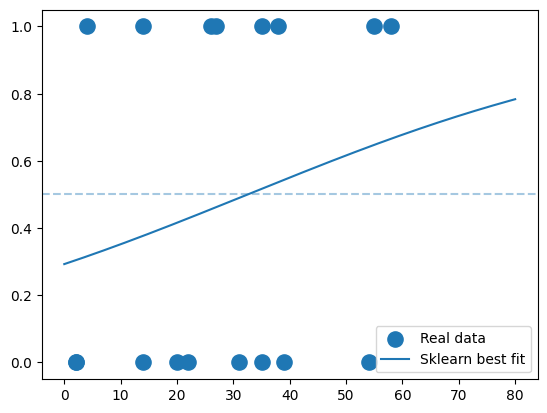

In [118]:
x_curve = np.linspace(0, 80, 300)

z_sklearn = model.coef_[0][0] * x_curve + model.intercept_[0]
p_sklearn = 1 / (1 + np.exp(-z_sklearn))

plt.scatter(x, y, s=120, label="Real data")
plt.plot(x_curve, p_sklearn, label="Sklearn best fit")
plt.axhline(0.5, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

In [120]:
## Both model cannot predict the outcome